# Re-import DESI DR1: include OBJTYPE and SPECTYPE

In [1]:
import glob
import os
from pathlib import Path

import lsdb
import nested_pandas as npd
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.table import Table
from dask.distributed import Client
from hats.io.validation import is_valid_catalog
from hats_import.catalog.arguments import ImportArguments
from hats_import.catalog.file_readers import InputReader
from hats_import.pipeline import pipeline_with_client

In [2]:
# Existing catalogs

main_directory = Path("/global/cfs/cdirs/desi/public/dr1/spectro/redux/iron")
input_path = main_directory / "healpix/"

In [3]:
# Output catalog

output_catalog_name = "desi-dr1-main-dark"

target_user_dir = Path("/global/cfs/cdirs/cosmo/www/users/olynn/")
os.makedirs(target_user_dir, exist_ok=True)
output_path = target_user_dir

print(f"Output path for HATS import: {output_path}")

Output path for HATS import: /global/cfs/cdirs/cosmo/www/users/olynn


## Redefine the Custom Input Reader

This time we'll add in OBJTYPE from FIBERMAP, and SPECTYPE from REDROCK

In [4]:
FIBERMAP_COLUMNS = [
    "TARGETID",  # Main ID
    "TARGET_RA",
    "TARGET_DEC",  # Spatial coordinates
    "OBJTYPE",  # Object type: TGT, SKY, NON, BAD
]  # Note - we'll grab the nested spectra columns below
REDROCK_COLUMNS = [
    "TARGETID",  # Main ID (matches fibermap)
    "Z",
    "ZERR",  # Basic redshift information
    "SPECTYPE",  # Best-fit spectral type: GALAXY, QSO, STAR
]


class DesiCoaddReader(InputReader):

    def __init__(self, chunksize=500_000):
        self.chunksize = chunksize

    def read(self, input_file, read_columns=None):
        input_file = str(input_file)
        redrock_file = input_file.replace("coadd-", "redrock-")

        # Read fibermap from coadd (1 row per unique target).
        with fits.open(input_file, memmap=True) as hdul:
            fibermap = Table(hdul["FIBERMAP"].data)[FIBERMAP_COLUMNS].to_pandas()
            fibermap = fibermap.astype(
                {col: fibermap[col].dtype.newbyteorder("=") for col in fibermap.columns}
            )

        # Read redshifts info.
        with fits.open(redrock_file, memmap=True) as hdul:
            redshifts = Table(hdul["REDSHIFTS"].data)[REDROCK_COLUMNS].to_pandas()
            redshifts = redshifts.astype(
                {col: redshifts[col].dtype.newbyteorder("=") for col in redshifts.columns}
            )

        # Join and set TARGETID as index.
        joined = fibermap.merge(redshifts, on="TARGETID", how="left")
        joined = npd.NestedFrame(joined.set_index("TARGETID"))

        # Add nested spectra columns from coadd file.
        with fits.open(input_file, memmap=True) as hdul:
            for cam in ["B", "R", "Z"]:
                wave = hdul[f"{cam}_WAVELENGTH"].data.astype("f8")
                flux = hdul[f"{cam}_FLUX"].data.astype("f4")  # (n_targets, n_wave)
                ivar = hdul[f"{cam}_IVAR"].data.astype("f4")
                mask = hdul[f"{cam}_MASK"].data.astype("i4")

                n_wave = len(wave)
                target_ids = joined.index

                flat = pd.DataFrame(
                    {
                        "wavelength": np.tile(wave, len(joined)),
                        "flux": flux.ravel(),
                        "ivar": ivar.ravel(),
                        "mask": mask.ravel(),
                    },
                    index=np.repeat(target_ids, n_wave),
                )

                joined = joined.join_nested(flat, f"spectra_{cam.lower()}")

        yield joined


def get_desi_coadd_files(input_path, surveys=("main",), programs=("dark",)):
    """Glob all coadd files across surveys and programs."""
    files = []
    for survey in surveys:
        for program in programs:
            pattern = os.path.join(input_path, survey, program, "*", "*", f"coadd-{survey}-{program}-*.fits")
            files.extend(glob.glob(pattern))
    return sorted(files)

## Run on small sample

In [ ]:
#! rm -r /global/cfs/cdirs/cosmo/www/users/olynn/desi-dr1-coadd-test

In [ ]:
! tree -L 2 $output_path

In [ ]:
test_files = [
    f"{input_path}/main/dark/0/0/coadd-main-dark-0.fits",
    f"{input_path}/main/dark/0/1/coadd-main-dark-1.fits",
]

output_catalog_name = "desi-dr1-coadd-test"

args = ImportArguments(
    input_file_list=test_files,
    file_reader=DesiCoaddReader(),
    ra_column="TARGET_RA",
    dec_column="TARGET_DEC",
    output_artifact_name=output_catalog_name,
    output_path=output_path,
    pixel_threshold=5_000,
    resume=False,
)

with Client(
        n_workers=4,
        memory_limit="16GB"
) as client:
    pipeline_with_client(args, client)

In [ ]:
output_catalog_path = target_user_dir / output_catalog_name

print(
    "Is valid catalog?",
    is_valid_catalog(output_catalog_path, verbose=True, fail_fast=False, strict=True)
)
test_catalog=lsdb.open_catalog(output_catalog_path)
test_catalog.head(5)

In [ ]:
test_catalog.original_schema

## Run on main/dark

In [5]:
# Make a dask client

client = Client(
    n_workers=32,
    threads_per_worker=2,
    memory_limit="14GB",   # 32 × 14 = 448 GB, well within 487 GB
)

# Set up dashboard port forwarding instructions for the user. 
# Note that the compute node hostname is needed to set up the ssh tunnel correctly.

import socket

username = os.getenv("USER")
current_compute_node = socket.gethostname()

print(f"1. In a local shell, run: ssh -L 8787:{current_compute_node}:8787 {username}@perlmutter.nersc.gov")
print("2. Enter password + OTP")
print(f"3. See Dask Dashboard in browser (on your local machine) at: http://localhost:8787/status")

1. In a local shell, run: ssh -L 8787:nid004254:8787 olynn@perlmutter.nersc.gov
2. Enter password + OTP
3. See Dask Dashboard in browser (on your local machine) at: http://localhost:8787/status


In [6]:
all_files = sorted(glob.glob(f'{input_path}/main/dark/*/*/coadd-main-dark-*.fits'))
print(f"Found {len(all_files)} coadd files")

Found 13494 coadd files


In [7]:
output_catalog_name = "desi-dr1-main-dark"

args = ImportArguments(
    input_file_list=all_files,
    file_reader=DesiCoaddReader(),
    ra_column="TARGET_RA",
    dec_column="TARGET_DEC",
    output_artifact_name=output_catalog_name,
    output_path=output_path,
    pixel_threshold=5_000,
    resume=False,
)

pipeline_with_client(args, client)

Catalog: Planning  :   0%|          | 0/4 [00:00<?, ?it/s]

Catalog: Mapping   :   0%|          | 0/13494 [00:00<?, ?it/s]

Catalog: Binning   :   0%|          | 0/2 [00:00<?, ?it/s]

Catalog: Splitting :   0%|          | 0/13494 [00:00<?, ?it/s]

Catalog: Reducing  :   0%|          | 0/5769 [00:00<?, ?it/s]

Catalog: Finishing :   0%|          | 0/6 [00:00<?, ?it/s]

Is valid catalog? True
700G	/global/cfs/cdirs/cosmo/www/users/olynn/desi-dr1-main-dark


(<Figure size 900x500 with 1 Axes>,
 <WCSAxes: title={'center': 'Coverage of desi-dr1-main-dark'}>)

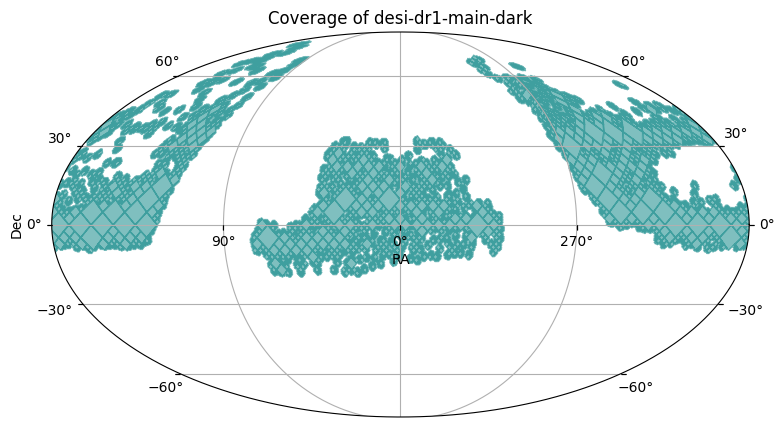

In [ ]:
output_catalog = "/global/cfs/cdirs/cosmo/www/users/olynn/desi-dr1-main-dark"

# Check if valid
print(
    "Is valid catalog?",
    is_valid_catalog(output_catalog, verbose=True, fail_fast=False, strict=True)
)
# Calculate size of the catalog on disk
! du -sh $output_catalog

# Plot the coverage
dark_main_catalog = lsdb.open_catalog(output_catalog)
dark_main_catalog.plot_coverage()

In [10]:
# Compute the first few rows
df = dark_main_catalog.head(5)
df

TARGETID  TARGET_RA  TARGET_DEC OBJTYPE         Z  \
_healpix_29                                                                
24531778214   39627785483846048  45.014136    0.019739     TGT  1.308415   
76347715933   39627785483846390  45.027565    0.029181     TGT  0.884491   
79430617729    2714981116149760  45.018964    0.029766     TGT  0.129609   
88592216842          -110547443  45.028689    0.031667     SKY  1.499465   
101138674798  39627785483846478  45.030526    0.041094     TGT  1.263249   

                  ZERR SPECTYPE  \
_healpix_29                       
24531778214   0.000399      QSO   
76347715933   0.000116   GALAXY   
79430617729   0.000009   GALAXY   
88592216842   0.000098   GALAXY   
101138674798   0.00009   GALAXY   

                                                      spectra_b  \
_healpix_29                                                       
24531778214   [{wavelength: 3600.0, flux: 2.924896, ivar: 0....   
76347715933   [{wavelength: 3600.0, flux: -3.560856, ivar: 0...   
79430617729   [{wavelength: 3600.0, flux: -5.12881, ivar: 0....   
88592216842   [{wavelength: 3600.0, flux: 1.824267, ivar: 0....   
101138674798  [{wavelength: 3600.0, flux: 0.314766, ivar: 0....   

                                                      spectra_r  \
_healpix_29                                                       
24531778214   [{wavelength: 5760.0, flux: 1.965631, ivar: 7....   
76347715933   [{wavelength: 5760.0, flux: 0.741585, ivar: 0....   
79430617729   [{wavelength: 5760.0, flux: 0.757192, ivar: 0....   
88592216842   [{wavelength: 5760.0, flux: -0.888818, ivar: 1...   
101138674798  [{wavelength: 5760.0, flux: 0.615158, ivar: 3....   

                                                      spectra_z  
_healpix_29                                                      
24531778214   [{wavelength: 7520.0, flux: 0.379682, ivar: 23...  
76347715933   [{wavelength: 7520.0, flux: -0.305626, ivar: 5...  
79430617729   [{wavelength: 7520.0, flux: 0.227893, ivar: 10...  
88592216842   [{wavelength: 7520.0, flux: -0.377297, ivar: 4...  
101138674798  [{wavelength: 7520.0, flux: 1.088948, ivar: 11...

In [20]:
# Plot spectra of a row

import matplotlib.pyplot as plt

def plot_spectra(df, target_idx):
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)
    colors = ["steelblue", "plum"]

    # Iterate over the three cameras and plot the spectra for the target at target_idx.
    for ax, cam in zip(axes, ["b", "r", "z"]):
        # Get the spectrum.
        spec = df[f"spectra_{cam}"].iloc[target_idx]

        # Plot flux on the primary y-axis.
        ax.plot(spec["wavelength"], spec["flux"], lw=0.8, color=colors[0], label="flux")
        
        # Plot ivar on the secondary y-axis.
        ax_twin = ax.twinx()
        ax_twin.plot(spec["wavelength"], spec["ivar"], lw=0.5, color=colors[1], alpha=0.5, label="ivar")
        ax_twin.set_ylabel("ivar", color=colors[1])
        ax_twin.tick_params(axis="y", labelcolor=colors[1])
        
        # Set labels and title for the primary y-axis.
        ax.set_ylabel("Flux (nanomaggies)") # https://desidatamodel.readthedocs.io/en/latest/DESI_SPECTRO_DATA/NIGHT/EXPID/fibermap-EXPID.html#required-data-table-columns:~:text=nanomaggies
        ax.set_title(f"Camera {cam.upper()}")
        ax.legend(loc="upper left")

    # Set x-axis label and overall figure title.
    axes[-1].set_xlabel("Wavelength (Å)")
    fig.suptitle(
        f"Row id={df.index[target_idx]}, "
        f"TARGETID={df['TARGETID'].iloc[target_idx]}, "
        f"OBJTYPE={df['OBJTYPE'].iloc[target_idx]}")
    plt.tight_layout()
    plt.show()

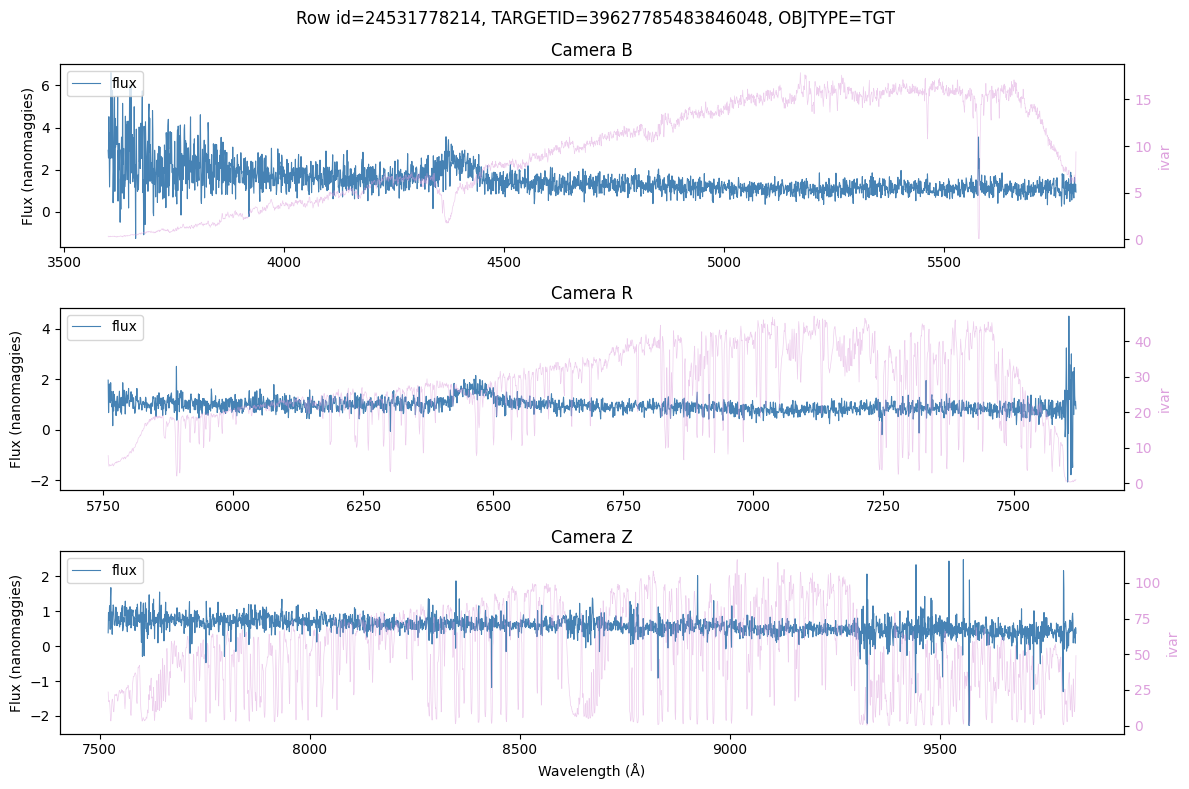

In [21]:
plot_spectra(df, 0)

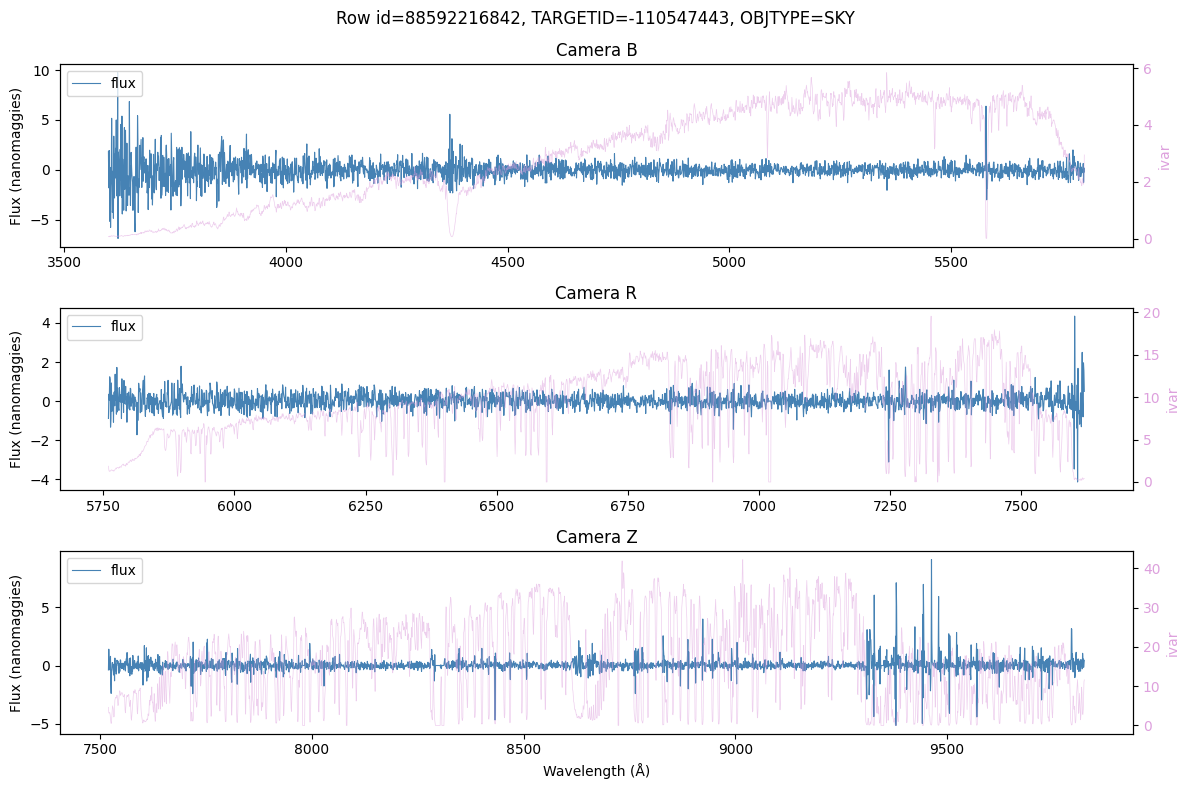

In [22]:
plot_spectra(df, 3)